# Brazil E-Commerce — Order Payments Analysis

Analysis of the **Olist `olist_order_payments_dataset.csv`** file.

Columns:
- `order_id` — key to the orders dataset
- `payment_sequential` — sequence number when an order is paid in multiple parts
- `payment_type` — credit_card / boleto / voucher / debit_card
- `payment_installments` — number of installments chosen
- `payment_value` — amount of this payment (BRL)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
pay = pd.read_csv("Data/olist_order_payments_dataset.csv")
print(f"Shape: {pay.shape[0]:,} rows x {pay.shape[1]} columns")
pay.head()

Shape: 103,886 rows x 5 columns


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [3]:
pay.info()
pay.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(pay.isna().sum())

print(f"\nFully duplicated rows: {pay.duplicated().sum():,}")
print(f"Distinct orders: {pay['order_id'].nunique():,}")
print(f"Rows with >1 payment record: {(pay['order_id'].value_counts() > 1).sum():,} orders")

Missing values per column:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Fully duplicated rows: 0
Distinct orders: 99,440
Rows with >1 payment record: 2,961 orders


## 3. Payment type breakdown

Count by type:
 payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64 

Total value by type (BRL):
 payment_type
credit_card    12542084.0
boleto          2869361.0
voucher          379437.0
debit_card       217990.0
not_defined           0.0
Name: payment_value, dtype: float64


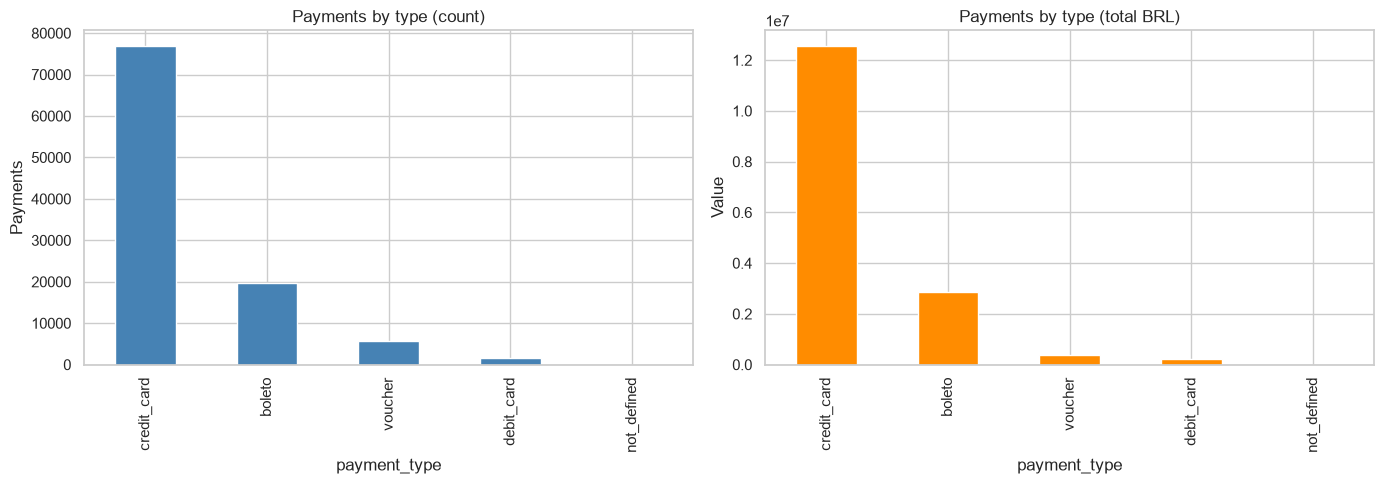

In [5]:
by_type = pay["payment_type"].value_counts()
value_by_type = pay.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
print("Count by type:\n", by_type, "\n")
print("Total value by type (BRL):\n", value_by_type.round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_type.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Payments by type (count)")
axes[0].set_ylabel("Payments")
value_by_type.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Payments by type (total BRL)")
axes[1].set_ylabel("Value")
plt.tight_layout()
plt.show()

## 4. Installments

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64


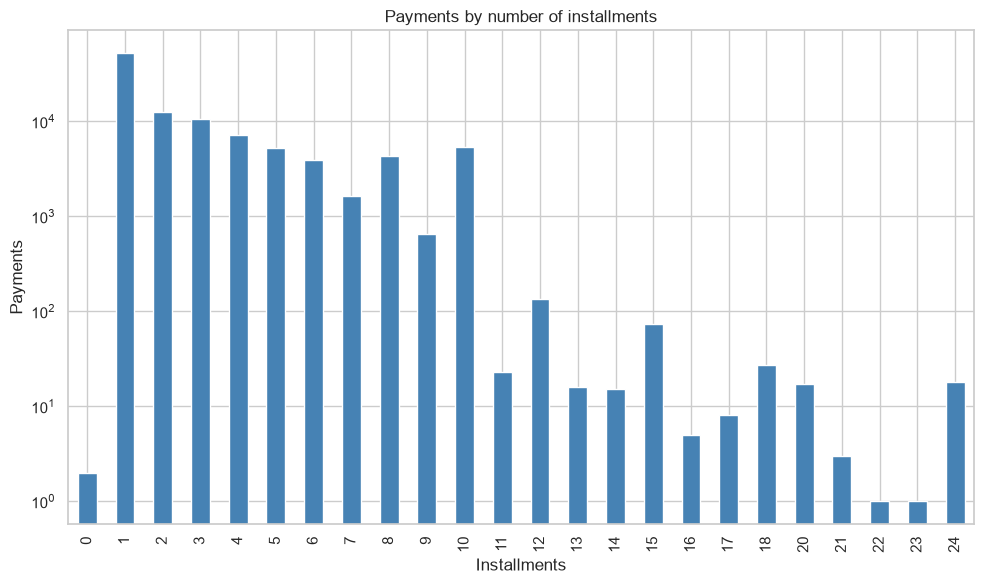

In [6]:
inst = pay["payment_installments"].value_counts().sort_index()
print(inst)

ax = inst.plot(kind="bar", color="steelblue")
ax.set_title("Payments by number of installments")
ax.set_xlabel("Installments")
ax.set_ylabel("Payments")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 5. Payment value distribution

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


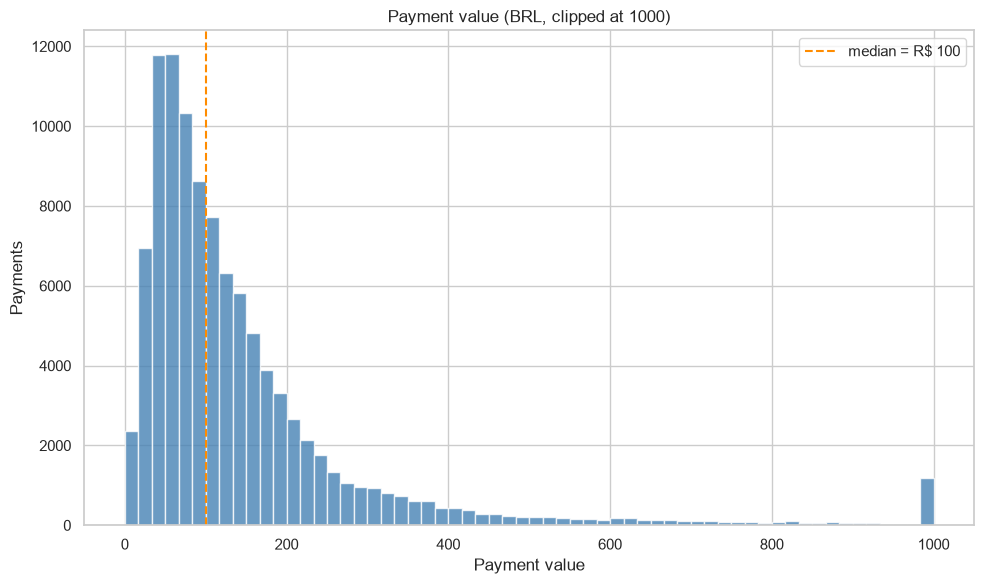

In [7]:
print(pay["payment_value"].describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pay["payment_value"].clip(0, 1000), bins=60, color="steelblue", alpha=0.8)
ax.axvline(pay["payment_value"].median(), color="darkorange", linestyle="--",
           label=f"median = R$ {pay['payment_value'].median():.0f}")
ax.set_title("Payment value (BRL, clipped at 1000)")
ax.set_xlabel("Payment value")
ax.set_ylabel("Payments")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
avg_value = pay.groupby("payment_type")["payment_value"].mean().sort_values(ascending=False)
print("Mean payment value by type (BRL):")
print(avg_value.round(2))

Mean payment value by type (BRL):
payment_type
credit_card    163.32
boleto         145.03
debit_card     142.57
voucher         65.70
not_defined      0.00
Name: payment_value, dtype: float64


## 6. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- Credit card dominates both in count and total value, followed by boleto.
- A single installment is most common, but multi-installment credit purchases are widespread.
- Payment values are right-skewed; vouchers tend to be small, boleto/credit larger.